In [44]:
import os
import cv2
import math
import random
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Camera  Parameters

## 1.1 Import Data from tone_curves

匯入資料，並定義像素值（Irradiance）和亮度（Brightness）

In [45]:
curve_path = './'
curve_name = os.path.join(curve_path, 'tone_curves.mat')
curve_inv_name = os.path.join(curve_path, 'tone_curves_inv.mat')
tone_curves = scipy.io.loadmat(curve_name)
tone_curves_inv = scipy.io.loadmat(curve_inv_name)

In [46]:
I = tone_curves['I'] # Irradiance
B = tone_curves['B'] # Brightness
I_inv = tone_curves_inv['invI']
B_inv = tone_curves_inv['invB']

Text(0.5, 1.0, 'Brightness')

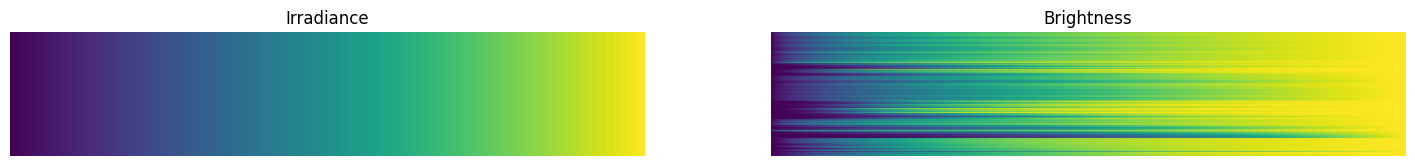

In [47]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(I)
plt.title('Irradiance')
plt.subplot(1, 2, 2)
plt.axis('off')
plt.imshow(B)
plt.title('Brightness')

In [48]:
# Tone Curves Parameters
tone_index = 170
B[tone_index]

array([  0.00000000e+00,   5.76713282e-05,   1.16315903e-04, ...,
         9.95653689e-01,   9.97825503e-01,   1.00000000e+00], dtype=float32)

## 1.2 Color Correction Matrix

定義了一個3×3的顏色校正矩陣（CCM），修正影像的顏色表現

In [49]:
ccm = np.array([1.0234, -0.2969, -0.2266, 
                -0.5625, 1.6328, -0.0469, 
                -0.0703, 0.2188, 0.6406])
ccm = np.reshape(ccm, (3, 3))
ccm = (ccm / np.tile(np.sum(ccm, axis=1), [3, 1]).T).T
ccm_inv = np.linalg.inv(np.copy(ccm))

## 1.3 White Balance

設定白平衡（White Balance, WB）參數，修正相機拍攝時的色溫偏移，使白色物體在不同光源下仍然顯示為白色

In [50]:
# White Balance Parameters
fr = 0.7715567349551743 # White balance coefficient for the red channel
fb = 0.9068480239589546 # White balance coefficient for the blue channel

# 2.  Load Image

匯入圖片

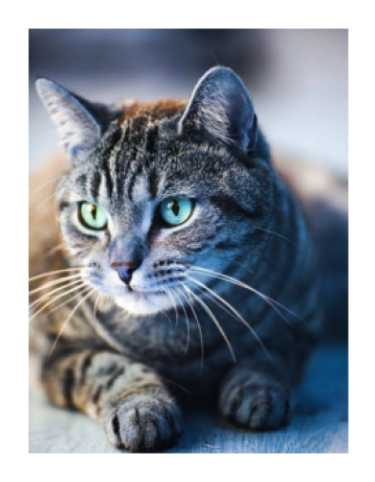

In [51]:
img = cv2.imread('./images/1.png')
plt.figure(figsize=(12, 6))
plt.axis('off')
plt.imshow(img)

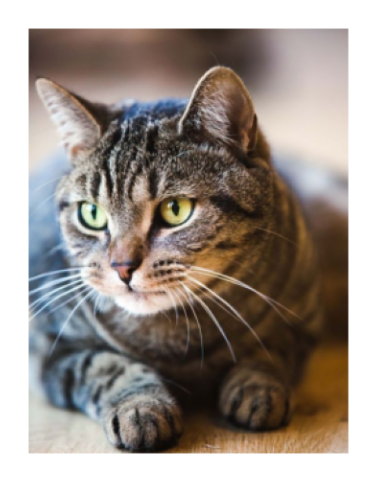

In [52]:
img = cv2.imread('./images/1.png')

# convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Normalize the image(convert from unit8 to float32)
img = img.astype('float32') / 255.0

plt.figure(figsize=(12, 6))
plt.axis('off')
plt.imshow(img)
plt.show()

# 3. Inverse ISP Process

## 3.1 Tone Mapping

True : 正向處理 (將高動態範圍（HDR) 影像映射到標準動態範圍（SDR），確保細節不過曝或過暗)

False : 逆向 HDR 映射 (從標準顯示範圍的 RGB 恢復到高動態範圍)

確保影像在顯示設備上能夠呈現適當的亮度和對比度

In [53]:
import numpy as np
import math

def tone_mapping(img, I, B, index=0, inv=False):
    '''
    Input:
        img: H*W*3 numpy array, input image.
        I: 201*1024 array, represents 201 tone curves for Irradiance.
        B: 201*1024 array, represents 201 tone curves for Brightness.
        index: int, choose which curve to use, default is 0
        inv: bool, judge whether tone mapping (False) or inverse tone mapping (True), default is False
    Output:
        output: H*W*3 numpy array, output image after (inverse) tone mapping.
    '''
    
    # Normalize the image if it's not in float32 format and has values above 1.0
    if img.dtype != np.float32 and img.max() > 1.0:
        img = img.astype(np.float32) / 255.0
    
    # Initialize the output image with the same shape as input
    output = np.zeros_like(img)
    
    # Apply tone mapping or inverse tone mapping for each color channel
    for i in range(3):
        if inv:
            output[:, :, i] = np.interp(img[:, :, i], B[index], I[index])
        else:
            output[:, :, i] = np.interp(img[:, :, i], I[index], B[index])
    output = np.clip(output, 0, 1) 

    return output



In [54]:
img_inverse_tone = tone_mapping(img, I_inv, B_inv, index=tone_index, inv=True)

Text(0.5, 1.0, 'Image after inverse tone')

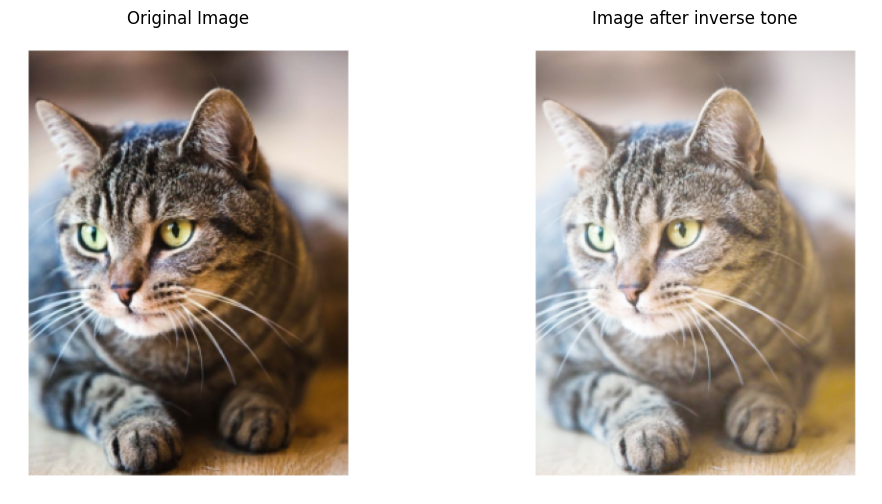

In [55]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(img)
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.axis('off')
plt.imshow(img_inverse_tone)
plt.title('Image after inverse tone')

## 3.2 from RGB to CIE XYZ
The CIE XYZ color space is a more universal color representation method that is independent of device characteristics and closer to the perception of the **human visual system**. The CIE XYZ color space is composed of three color components: X, Y, and Z. Among these, X and Y represent the **brightness** and **saturation** of the color, while Z represents the **hue** of the color.

RGB（紅、綠、藍）是一種設備依賴（device-dependent）的顏色空間，不同設備（例如相機、螢幕）會有不同的顏色表現
因此，希望進行更標準化的顏色處理時，常常會將 RGB 轉換到 CIE XYZ 顏色空間

In [56]:
#from color_correction import RGB2XYZ
import skimage.color
img_inverse_tone_XYZ = skimage.color.rgb2xyz(img_inverse_tone)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0116985..1.08875].


Text(0.5, 1.0, 'Image after CIE')

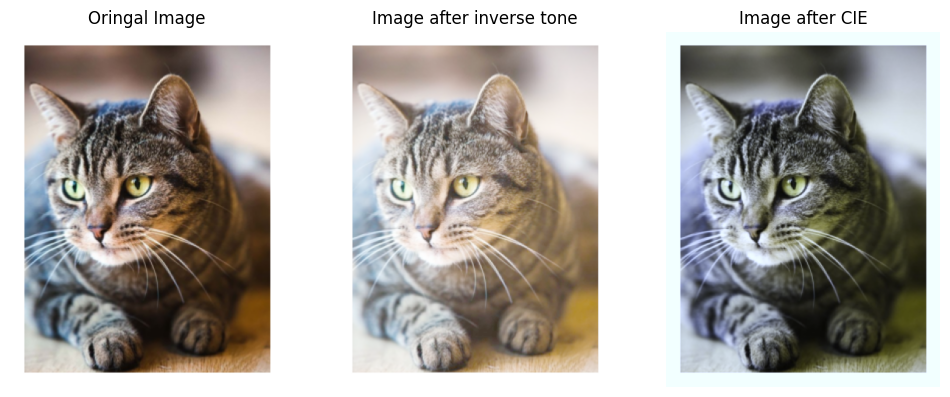

In [57]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.axis('off')
plt.imshow(img)
plt.title('Oringal Image')
plt.subplot(1, 3, 2)
plt.axis('off')
plt.imshow(img_inverse_tone)
plt.title('Image after inverse tone')
plt.subplot(1, 3, 3)
plt.axis('off')
plt.imshow(img_inverse_tone_XYZ)
plt.title('Image after CIE')

## 3.3. Color Correction

反向應用 CCM，恢復原始感測器記錄的顏色

In [58]:
def color_correction(img, ccm):
    '''
    Input:
        img: H*W*3 numpy array, input image
        ccm: 3*3 numpy array, color correction matrix
    Output:
        output: H*W*3 numpy array, output image after color correction
    '''
    
    img2 = img.reshape((img.shape[0] * img.shape[1], 3))
    output = np.matmul(img2, ccm)   
    return output.reshape(img.shape).astype(img.dtype)


In [59]:
ccm

array([[ 2.04720944, -0.54963846, -0.08908884],
       [-0.59391878,  1.59546609,  0.27727791],
       [-0.45329066, -0.04582763,  0.81181092]])

In [60]:
img_inverse_ccm = color_correction(img_inverse_tone_XYZ, ccm)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0116985..1.08875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0165186..1.07647].


Text(0.5, 1.0, 'Image after CCM')

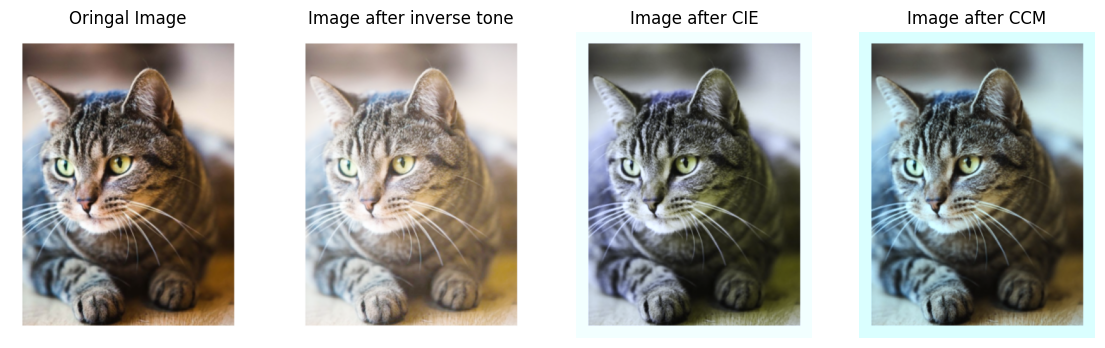

In [61]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 4, 1)
plt.axis('off')
plt.imshow(img)
plt.title('Oringal Image')
plt.subplot(1, 4, 2)
plt.axis('off')
plt.imshow(img_inverse_tone)
plt.title('Image after inverse tone')
plt.subplot(1, 4, 3)
plt.axis('off')
plt.imshow(img_inverse_tone_XYZ)
plt.title('Image after CIE')
plt.subplot(1, 4, 4)
plt.axis('off')
plt.imshow(img_inverse_ccm)
plt.title('Image after CCM')

## 3.4 Mosaic

將 RGB 轉回 Bayer Pattern（感測器的原始像素排列），讓每個像素只存一個顏色（R/G/B）

In [62]:
from colour_demosaicing import demosaicing_CFA_Bayer_Malvar2004

def mosaic(img, pattern):
    '''
    Input:
        img: H*W*3 numpy array, input image.
        pattern: string, 4 different Bayer patterns (GRBG, RGGB, GBRG, BGGR)
    Output:
        output: H*W numpy array, output image after mosaic.
    '''
    # Get image shape
    H, W, _ = img.shape
    output = np.zeros((H, W))

    # Bayer mask 2x2
    pattern_dict = {
        'RGGB': [[0, 1], [1, 2]],  # R, G; G, B
        'BGGR': [[2, 1], [1, 0]],  # B, G; G, R
        'GRBG': [[1, 0], [2, 1]],  # G, R; B, G
        'GBRG': [[1, 2], [0, 1]]   # G, B; R, G
    }

    # Check pattern
    if pattern not in pattern_dict:
        raise ValueError("Unsupported Bayer pattern.")

    # Assign pixel values
    channels = pattern_dict[pattern]

    for i in range(H):
        for j in range(W):
            channel = channels[i % 2][j % 2]
            output[i, j] = img[i, j, channel] 

    return output

def demosaic(img, pattern):
    '''
    Input:
        img: H*W numpy array, input RAW image.
        pattern: string, 4 different Bayer patterns (GRBG, RGGB, GBRG, BGGR)
    Output:
        output: H*W*3 numpy array, output de-mosaic image.
    '''
    #### Using Python colour_demosaicing library
    #### You can write your own version, too
    output = demosaicing_CFA_Bayer_Malvar2004(img,pattern)
    output = np.clip(output, 0, 1)

    return output

In [63]:

pattern='RGGB'
img_mosaic = mosaic(img_inverse_ccm, pattern=pattern)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0116985..1.08875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0165186..1.07647].


Text(0.5, 1.0, 'Image after mosaic')

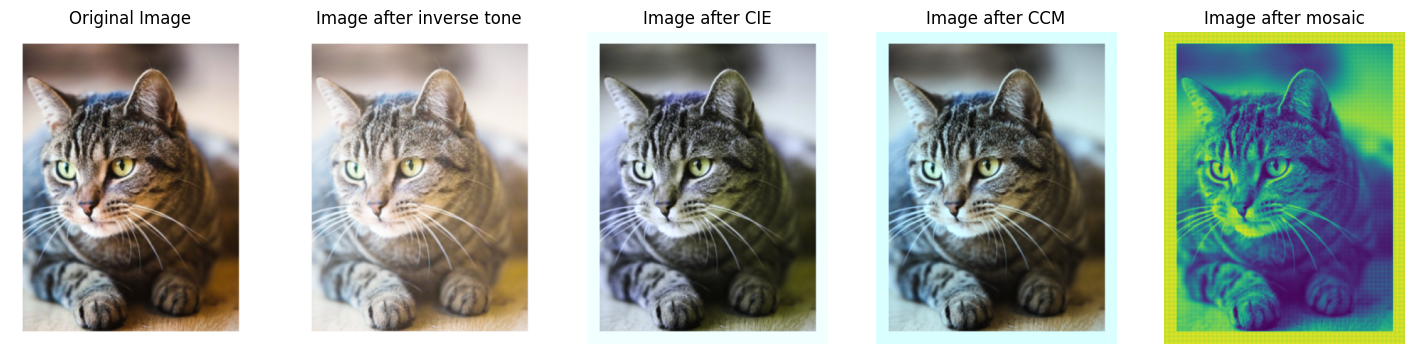

In [64]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 5, 1)
plt.axis('off')
plt.imshow(img)
plt.title('Original Image')
plt.subplot(1, 5, 2)
plt.axis('off')
plt.imshow(img_inverse_tone)
plt.title('Image after inverse tone')
plt.subplot(1, 5, 3)
plt.axis('off')
plt.imshow(img_inverse_tone_XYZ)
plt.title('Image after CIE')
plt.subplot(1, 5, 4)
plt.axis('off')
plt.imshow(img_inverse_ccm)
plt.title('Image after CCM')
plt.subplot(1, 5, 5)
plt.axis('off')
plt.imshow(img_mosaic)
plt.title('Image after mosaic')

## 3.5 Inverse AWB
1. Create a numpy array with shape of input RAW image.
2. According to the given Bayer pattern, fill the fr into  correspinding red channel position and fb into correspinding  blue channel position. Fill 1 into green channel position otherwise.  

逆向白平衡，使影像回到未校正的感測器輸出

In [65]:
def generate_wb_mask(img, pattern, fr, fb):
    '''
    Input:
        img: H*W numpy array, RAW image
        pattern: string, 4 different Bayer patterns (GRBG, RGGB, GBRG, BGGR)
        fr: float, white balance factor of red channel
        fb: float, white balance factor of blue channel 
    Output:
        mask: H*W numpy array, white balance mask
    '''
    ########################################################################
    # TODO:                                                                #
    #   1. Create a numpy array with shape of input RAW image.             #
    #   2. According to the given Bayer pattern, fill the fr into          #
    #      correspinding red channel position and fb into correspinding    #
    #      blue channel position. Fill 1 into green channel position       #
    #      otherwise.                                                      #
    ########################################################################
    import numpy as np

def generate_wb_mask(img, pattern, fr, fb):
    """
    Input:
    img: H*W numpy array, RAW image
    pattern: string, 4 different Bayer patterns (GRBG, RGGB, GBRG, BGGR)
    fr: float, white balance factor of red channel
    fb: float, white balance factor of blue channel

    Output:
    mask: H*W numpy array, white balance mask
    """

    # Step 1: Create a numpy array with the same shape as input RAW image
    mask = np.ones_like(img, dtype=np.float32)

    # Step 2: Fill white balance mask according to the Bayer pattern
    if pattern == 'RGGB':
        mask[0::2, 0::2] = fr  # Red
        mask[1::2, 1::2] = fb  # Blue
    elif pattern == 'GRBG':
        mask[0::2, 1::2] = fr  # Red
        mask[1::2, 0::2] = fb  # Blue
    elif pattern == 'GBRG':
        mask[0::2, 1::2] = fb  # Blue
        mask[1::2, 0::2] = fr  # Red
    elif pattern == 'BGGR':
        mask[0::2, 0::2] = fb  # Blue
        mask[1::2, 1::2] = fr  # Red
    else:
        raise ValueError("Unsupported Bayer pattern")
        
    return mask

In [66]:
fr = 0.7715567349551743
fb = 0.9068480239589546
wb_mask = generate_wb_mask(img_mosaic, pattern, fr, fb)
img_Inverse_WB = img_mosaic  * wb_mask

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0116985..1.08875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0165186..1.07647].


Text(0.5, 1.0, 'Image after Inverse WB')

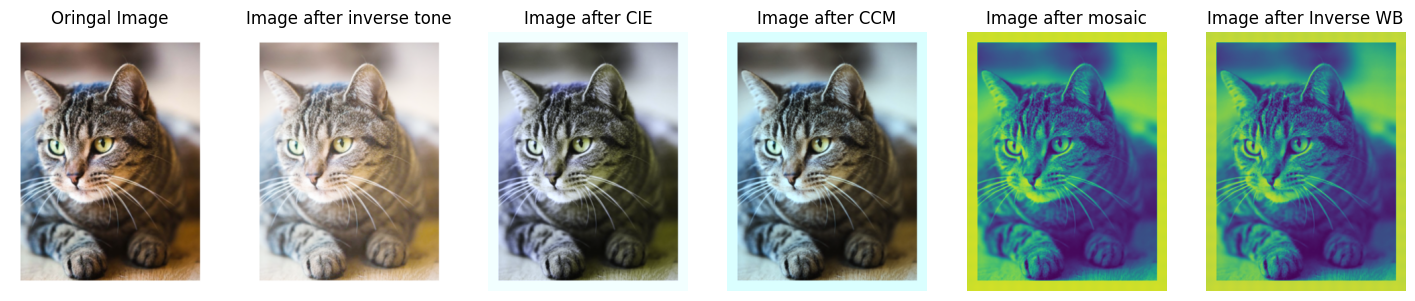

In [67]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 6, 1)
plt.axis('off')
plt.imshow(img)
plt.title('Oringal Image')
plt.subplot(1, 6, 2)
plt.axis('off')
plt.imshow(img_inverse_tone)
plt.title('Image after inverse tone')
plt.subplot(1, 6, 3)
plt.axis('off')
plt.imshow(img_inverse_tone_XYZ)
plt.title('Image after CIE')
plt.subplot(1, 6, 4)
plt.axis('off')
plt.imshow(img_inverse_ccm)
plt.title('Image after CCM')
plt.subplot(1, 6, 5)
plt.axis('off')
plt.imshow(img_mosaic)
plt.title('Image after mosaic')
plt.subplot(1, 6, 6)
plt.axis('off')
plt.imshow(img_Inverse_WB)
plt.title('Image after Inverse WB')

# 4. ISP Process

使影像適合人眼觀看，符合標準顯示設備

## 4.1 AWB

修正光源影響，使白色物體看起來是白色

In [68]:
wb_mask = generate_wb_mask(img_Inverse_WB, pattern, 1/fr, 1/fb)
img_WB = img_Inverse_WB * wb_mask
img_WB = np.clip(img_WB, 0, 1)

Text(0.5, 1.0, 'Image after WG')

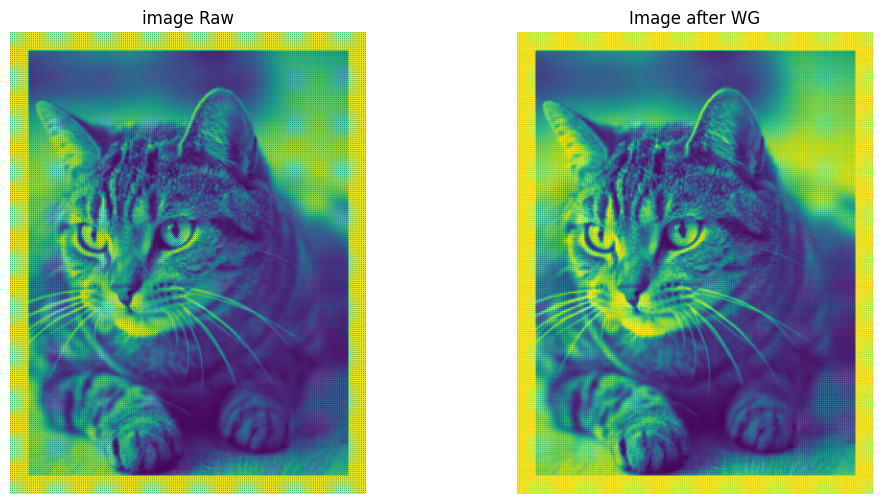

In [69]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1);plt.axis('off')
plt.imshow(img_Inverse_WB)
plt.title('image Raw')
plt.subplot(1, 2, 2);plt.axis('off')
plt.imshow(img_WB)
plt.title('Image after WG')

## 4.2 Demosaic

將感測器的單色像素（Bayer Pattern）轉換成完整的 RGB 圖像

In [70]:
img_demosaic = demosaic(img_WB, pattern=pattern) #pattern='RGGB'

Text(0.5, 1.0, 'Image after demosaic')

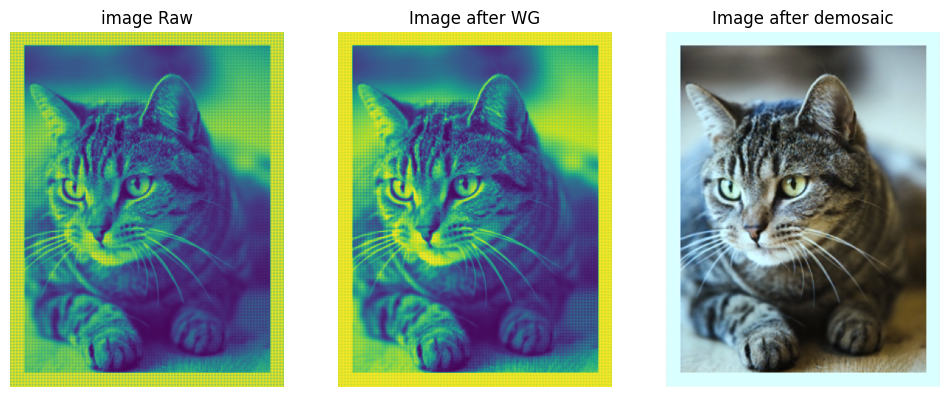

In [71]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1);plt.axis('off')
plt.imshow(img_Inverse_WB)
plt.title('image Raw')
plt.subplot(1, 3, 2);plt.axis('off')
plt.imshow(img_WB)
plt.title('Image after WG')
plt.subplot(1, 3, 3);plt.axis('off')
plt.imshow(img_demosaic)
plt.title('Image after demosaic')

## 4.3 Color Correction

調整相機感測器的色彩，使其更符合標準顯示

In [72]:
img_color_correction = color_correction(img_demosaic, ccm_inv)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0214424956689..1.04883508991].


Text(0.5, 1.0, 'Image after Color Correction')

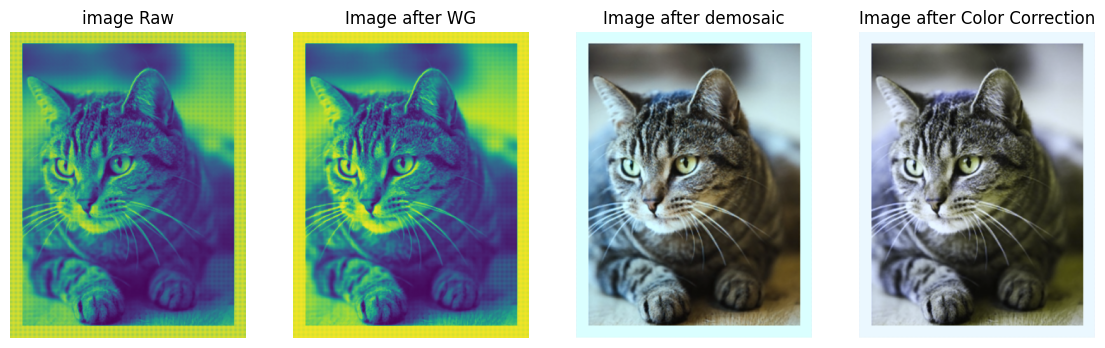

In [73]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 4, 1);plt.axis('off')
plt.imshow(img_Inverse_WB)
plt.title('image Raw')
plt.subplot(1, 4, 2);plt.axis('off')
plt.imshow(img_WB)
plt.title('Image after WG')
plt.subplot(1, 4, 3);plt.axis('off')
plt.imshow(img_demosaic)
plt.title('Image after demosaic')
plt.subplot(1, 4, 4);plt.axis('off')
plt.imshow(img_color_correction)
plt.title('Image after Color Correction')

## 4.4 XYZ2RGB

將標準化的 CIE XYZ 顏色轉換回適合顯示的 RGB，將標準化顏色轉回可顯示格式


In [74]:
from skimage.color import xyz2rgb
img_RGB = xyz2rgb(img_color_correction)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0214424956689..1.04883508991].


Text(0.5, 1.0, 'Image after XYZ2RGB')

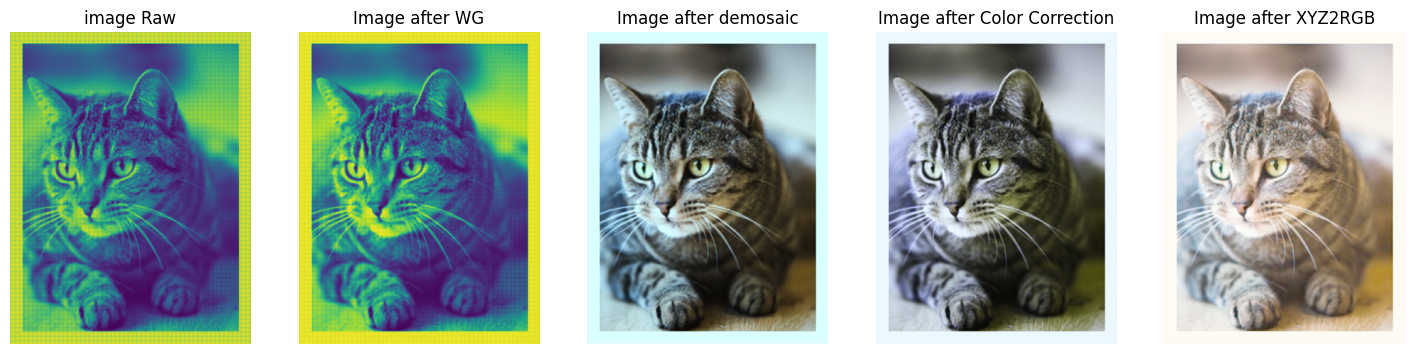

In [75]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 5, 1);plt.axis('off')
plt.imshow(img_Inverse_WB)
plt.title('image Raw')
plt.subplot(1, 5, 2);plt.axis('off')
plt.imshow(img_WB)
plt.title('Image after WG')
plt.subplot(1, 5, 3);plt.axis('off')
plt.imshow(img_demosaic)
plt.title('Image after demosaic')
plt.subplot(1, 5, 4);plt.axis('off')
plt.imshow(img_color_correction)
plt.title('Image after Color Correction')
plt.subplot(1, 5, 5);plt.axis('off')
plt.imshow(img_RGB)
plt.title('Image after XYZ2RGB')

## 4.5 tone_mapping

正向處理 : 壓縮亮度範圍，確保細節不過曝或過暗，適應 SDR 顯示

In [76]:
img_tm = tone_mapping(img_RGB, I, B, index=tone_index, inv=False) 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0214424956689..1.04883508991].


Text(0.5, 1.0, 'Image after tone mapping')

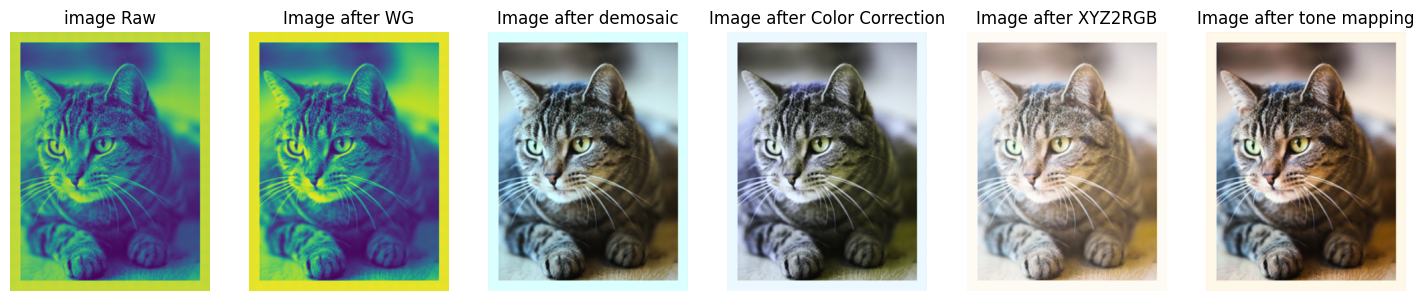

In [77]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 6, 1);plt.axis('off')
plt.imshow(img_Inverse_WB)
plt.title('image Raw')
plt.subplot(1, 6, 2);plt.axis('off')
plt.imshow(img_WB)
plt.title('Image after WG')
plt.subplot(1, 6, 3);plt.axis('off')
plt.imshow(img_demosaic)
plt.title('Image after demosaic')
plt.subplot(1, 6, 4);plt.axis('off')
plt.imshow(img_color_correction)
plt.title('Image after Color Correction')
plt.subplot(1, 6, 5);plt.axis('off')
plt.imshow(img_RGB)
plt.title('Image after XYZ2RGB')
plt.subplot(1, 6, 6);plt.axis('off')
plt.imshow(img_tm)
plt.title('Image after tone mapping')

Text(0.5, 1.0, 'Image after inverse process')

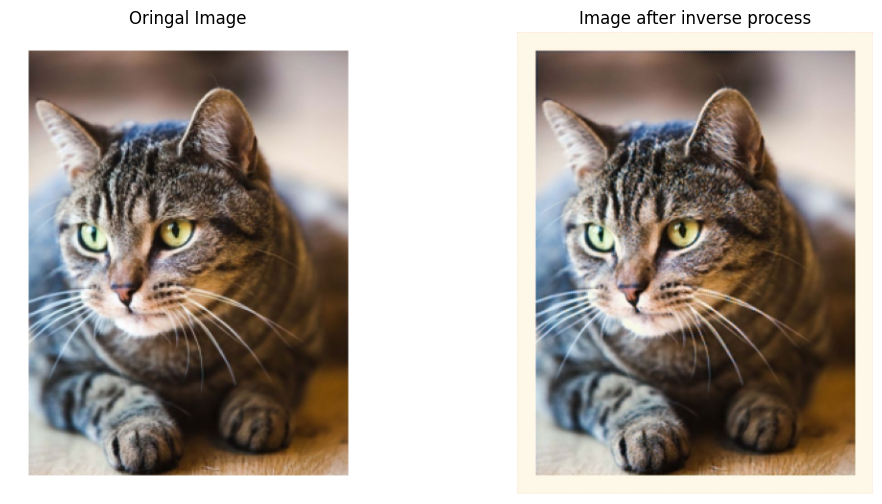

In [78]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1);plt.axis('off')
plt.imshow(img)
plt.title('Oringal Image')
plt.subplot(1, 2, 2);plt.axis('off')
plt.imshow(img_tm)
plt.title('Image after inverse process')

## Peak Signal-to-Noise Ratio

計算 Peak Signal-to-Noise Ratio (PSNR，峰值信噪比)，用來衡量兩張影像之間的相似度

In [79]:
def calculate_psnr(img1, img2):
    '''
    Input:
        img1, img2: H*W*3 numpy array
    Output:
        psnr: the peak signal-to-noise ratio value
    '''
    # Calculate the mean square error
    mse = np.mean((img1 - img2) ** 2)
    
    # Assume the image is in 0~255
    max_value = 255.0 
    
    # if two images are the same, return inf
    if mse == 0: 
        return float('inf')
    
    # Calculate PSNR
    return 20 * np.log10(max_value / (np.sqrt(mse))) 


In [80]:
print(f"PSNR: {calculate_psnr(img, img_tm):.2f} db")

PSNR: 80.04 db
